# 📉 Model Drift Detector

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/model-drift-detector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/model-drift-detector/demo.ipynb)

> **Models degrade silently in production.** Accuracy doesn't send you an email when it starts slipping. This detector watches the *inputs* and *outputs* of a live model and alerts the moment their distribution drifts away from training.

**This notebook covers:**
1. What drift is, and why you can catch it *without labels*
2. **Population Stability Index (PSI)** — built from scratch
3. Detecting feature drift + prediction drift on sample data
4. A PSI chart with the alert bands
5. Try your own reference vs. production data


## Step 1 — Why drift, and why PSI

In production you usually get the *ground truth* labels late (or never). But you always have the model's **inputs** and **predictions** right now. If the incoming feature distribution drifts away from what the model trained on, performance is almost certainly degrading — silently.

**Population Stability Index (PSI)** measures how much a distribution shifted between a reference (training) sample and a production sample. The credit-risk convention:

| PSI | Meaning |
|---|---|
| < 0.10 | no meaningful shift |
| 0.10 – 0.25 | moderate shift — investigate |
| ≥ 0.25 | significant shift — alert |


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd

PSI_MODERATE, PSI_SIGNIFICANT = 0.10, 0.25


def psi(reference: np.ndarray, production: np.ndarray, bins: int = 10) -> float:
    """PSI with quantile bins from the reference; epsilon guards against empty bins."""
    reference = np.asarray(reference, float)
    production = np.asarray(production, float)
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if edges.size < 2:
        return 0.0
    edges[0], edges[-1] = -np.inf, np.inf
    ref = np.histogram(reference, edges)[0] / len(reference) + 1e-6
    prod = np.histogram(production, edges)[0] / len(production) + 1e-6
    return float(np.sum((prod - ref) * np.log(prod / ref)))


def severity(v: float) -> str:
    return "significant" if v >= PSI_SIGNIFICANT else ("moderate" if v >= PSI_MODERATE else "none")


# sanity check: same distribution -> ~0, shifted -> large
rng = np.random.default_rng(0)
base = rng.normal(0, 1, 5000)
same = rng.normal(0, 1, 5000)
shifted = rng.normal(1.2, 1, 5000)
print(f"PSI(same)    = {psi(base, same):.4f}  -> {severity(psi(base, same))}")
print(f"PSI(shifted) = {psi(base, shifted):.4f}  -> {severity(psi(base, shifted))}")


PSI(same)    = 0.0055  -> none
PSI(shifted) = 1.3327  -> significant


## Step 2 — Sample data: a silently degrading model

Reference = the training window. Production = last week's live traffic, where the `income` feature has shifted (maybe we launched in a wealthier market) and the model's `score` output has drifted with it. `age` and `tenure_months` stay stable — a good detector should leave those alone and only flag what actually moved.


In [2]:
def make_data(drift_strength=1.5, n=2000, seed=42):
    r = np.random.default_rng(seed)
    ref = pd.DataFrame({
        "age": r.normal(40, 10, n),
        "income": r.normal(60_000, 15_000, n),
        "tenure_months": r.gamma(2.0, 12, n),
        "score": np.clip(r.beta(2, 5, n), 0, 1),
    })
    prod = pd.DataFrame({
        "age": r.normal(40, 10, n),
        "income": r.normal(60_000 + drift_strength * 12_000, 15_000, n),
        "tenure_months": r.gamma(2.0, 12, n),
        "score": np.clip(r.beta(2, 5 - min(drift_strength, 3.5), n), 0, 1),
    })
    return ref, prod


ref, prod = make_data(drift_strength=1.5)
print("Reference means:\n", ref.mean().round(1).to_string())
print("\nProduction means:\n", prod.mean().round(1).to_string())


Reference means:
 age                 39.4
income           60241.8
tenure_months       24.0
score                0.3

Production means:
 age                 40.6
income           78956.8
tenure_months       24.3
score                0.4


## Step 3 — Detect drift across every feature + the prediction

Run PSI on each numeric feature and on the model's own `score` output. Anything in the *significant* band becomes an alert reason. Prediction drift is a stand-in for concept drift you can compute with zero labels.


In [3]:
def detect(ref, prod, prediction_col="score", bins=10):
    rows, reasons = [], []
    for col in ref.columns:
        v = psi(ref[col].to_numpy(), prod[col].to_numpy(), bins)
        rows.append({"feature": col, "psi": round(v, 4), "severity": severity(v),
                     "ref_mean": round(ref[col].mean(), 2), "prod_mean": round(prod[col].mean(), 2)})
        if severity(v) == "significant":
            label = "Prediction distribution" if col == prediction_col else f"Feature '{col}'"
            reasons.append(f"{label} drifted significantly (PSI={v:.3f}).")
    return pd.DataFrame(rows), reasons


table, reasons = detect(ref, prod)
print(table.to_string(index=False))
print("\n" + ("🚨 ALERT:\n" + "\n".join(f"  - {r}" for r in reasons) if reasons else "✅ no drift"))


      feature    psi    severity  ref_mean  prod_mean
          age 0.0148        none     39.45      40.61
       income 1.3981 significant  60241.82   78956.84
tenure_months 0.0093        none     24.03      24.31
        score 0.2022    moderate      0.28       0.36

🚨 ALERT:
  - Feature 'income' drifted significantly (PSI=1.398).


## Step 4 — Visualize the drift and the alert bands

Green = stable, amber = moderate, red = significant. The dashed lines are the decision thresholds. `income` blows past the significant line; `score` sits in the moderate zone; the stable features hug zero.


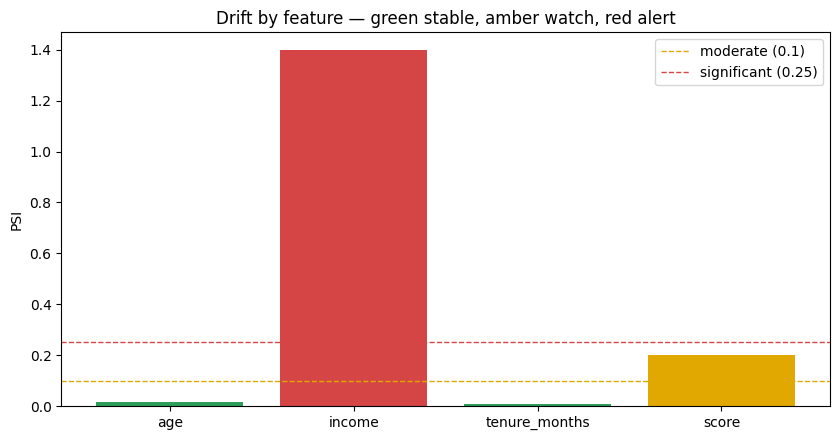

In [4]:
import matplotlib.pyplot as plt

cmap = {"none": "#2e9e5b", "moderate": "#e0a800", "significant": "#d64545"}
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(table["feature"], table["psi"], color=[cmap[s] for s in table["severity"]])
ax.axhline(PSI_MODERATE, color="#e0a800", ls="--", lw=1, label=f"moderate ({PSI_MODERATE})")
ax.axhline(PSI_SIGNIFICANT, color="#d64545", ls="--", lw=1, label=f"significant ({PSI_SIGNIFICANT})")
ax.set_ylabel("PSI")
ax.set_title("Drift by feature — green stable, amber watch, red alert")
ax.legend()
plt.tight_layout()
plt.savefig("drift_psi.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- **No labels needed:** PSI on inputs + predictions catches degradation before the accuracy metric ever updates.
- **Per-feature attribution:** you don't just learn *that* the model drifted — you learn *which* feature moved, so you know where to look.
- **Alert bands, not vibes:** the 0.10 / 0.25 thresholds turn a fuzzy "seems off" into an actionable alert you can wire to Slack or PagerDuty.

The full app lets you dial drift strength live, adjust the PSI bins, and fire a real webhook alert via `ALERT_WEBHOOK_URL`.


## Try your own data

Swap in your own reference and production frames (same columns), then re-run. Set `prediction_col` to your model's output column to monitor prediction drift too.


In [5]:
# my_ref = pd.read_csv("training_snapshot.csv")
# my_prod = pd.read_csv("last_week_production.csv")
# table, reasons = detect(my_ref, my_prod, prediction_col="pred_proba", bins=10)
# print(table.to_string(index=False))
# print("ALERT" if reasons else "no drift", reasons)


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 49, AI Agent Workshop.

For the interactive Streamlit version (live drift slider, PSI-bin control, and webhook alerting):
```bash
pip install -r requirements.txt
streamlit run app.py
```
